# 04 — Retrieval Analysis

Inspects the **Retriever** module: SigLIP2 (or mock) embeddings searched against a pre-built FAISS gallery index.

`Retriever` only *loads* a pre-built index — it never builds one at runtime (that's `GalleryIndexBuilder`, run offline via `BuildPipeline`). This notebook therefore assumes the index already exists at `retrieval.gallery_index_path`; an optional, explicitly-gated cell can build it if missing.

Covered in this notebook:

1. Setup and helpers
2. Load `Retriever` (pre-built gallery index required)
3. Gallery index overview (size, embedding dim, images per product)
4. Retrieve Top-K for a real crop (Detector → Cropper → Retriever)
5. Visualize a query crop next to its Top-K gallery matches
6. Self-retrieval sanity check (does a gallery image retrieve itself as Top-1?)
7. Top-1 similarity-score distribution across a batch of crops
8. Retrieval accuracy against benchmark ground truth (`category_id` == `product_id`)
9. Summary

> Note: the `siglip2` backend downloads/loads `google/siglip2-base-patch16-224` and benefits from a CUDA GPU. If the gallery index hasn't been built yet, most of this notebook will simply report that and skip — see §2.


## 1. Environment setup

In [50]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
assert (PROJECT_ROOT / "configs" / "config.yaml").is_file()

Project root: g:\VsCode\Python\DACN\stocktaking_ai_mini


In [51]:
import json
import random
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.core.config import load_config
from src.detection.detector import Detector
from src.detection.cropper import Cropper
from src.retrieval.retriever import Retriever
from src.models.models import BoundingBox, CropImage, ImageData, RefinementResult
from src.core.utils import generate_id

pd.set_option("display.max_colwidth", 80)
%matplotlib inline

In [52]:
config = load_config()

print(f"Retrieval backend:    {config.retrieval.backend}")
print(f"Embedding dim:        {config.retrieval.embedding_dim}")
print(f"Top-K:                {config.retrieval.top_k}")
print(f"Gallery index path:   {config.resolve_path(config.retrieval.gallery_index_path)}")
print(f"Gallery metadata path:{config.resolve_path(config.retrieval.gallery_metadata_path)}")
print(f"Decision similarity threshold: {config.decision.similarity_threshold}")

Retrieval backend:    siglip2
Embedding dim:        768
Top-K:                5
Gallery index path:   G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache\gallery_index.faiss
Gallery metadata path:G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache\gallery_metadata.json
Decision similarity threshold: 0.55


In [53]:
def load_image_data(image_path: Path) -> ImageData:
    """Loads an image file from disk into an ImageData DTO safely on Windows with Unicode paths."""
    image_path = Path(image_path)

    if not image_path.is_file():
        raise FileNotFoundError(f"Could not read image because file does not exist: {image_path}")
    try:
        data = np.fromfile(str(image_path), dtype=np.uint8)

        if data.size == 0:
            raise ValueError(f"Image file is empty: {image_path}")

        image_array = cv2.imdecode(data, cv2.IMREAD_COLOR)

        if image_array is None:
            raise ValueError(f"OpenCV could not decode image: {image_path}")

    except Exception as exc:
        raise ValueError(f"Failed to load image '{image_path}': {exc}") from exc

    height, width = image_array.shape[:2]

    return ImageData(
        image_id=image_path.stem,
        source_path=str(image_path),
        image_array=image_array,
        width=width,
        height=height,
    )


def show_image_bgr(ax, image_array_bgr: np.ndarray, title: str = ""):
    ax.imshow(cv2.cvtColor(image_array_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=9)
    ax.axis("off")


IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

## 2. Load the Retriever

Loading fails with `FileNotFoundError` if the gallery index / metadata / product catalog have not been built yet. Set `RUN_BUILD_IF_MISSING = True` below to build them here (downloads the embedding model on first run; can take a while) — otherwise run `python run.py` once (without `--skip-build`), or `BuildPipeline(config).run()`, outside this notebook first.

In [54]:
RUN_BUILD_IF_MISSING = True

try:
    retriever = Retriever(config)
    print(f"Retriever loaded. Gallery size: {retriever._index.ntotal} vectors.")
except FileNotFoundError as exc:
    print(f"Retriever could not be loaded: {exc}")
    retriever = None

    if RUN_BUILD_IF_MISSING:
        from src.pipeline.build import BuildPipeline

        build_config = config.model_copy(update={
            "catalog": config.catalog.model_copy(update={"build_metadata": True}),
            "retrieval": config.retrieval.model_copy(update={"build_gallery_index": True}),
        })
        BuildPipeline(build_config).run()
        retriever = Retriever(config)
        print(f"Build complete. Gallery size: {retriever._index.ntotal} vectors.")

2026-09-03 19:25:39 | INFO     | src.retrieval.backends.siglip2 | Loading SigLIP2 model 'google/siglip2-base-patch16-224' on device='cuda' dtype='torch.float16'


Loading weights: 100%|██████████| 408/408 [00:04<00:00, 100.63it/s]


2026-09-03 19:25:51 | INFO     | src.retrieval.backends.siglip2 | SigLIP2 CUDA memory after load: allocated=1.68 GB reserved=1.78 GB
2026-09-03 19:25:51 | INFO     | src.retrieval.backends.siglip2 | Siglip2Backend initialized (model_name='google/siglip2-base-patch16-224' device='cuda' dtype='torch.float16')
2026-09-03 19:25:51 | INFO     | src.retrieval.retriever | Loading gallery FAISS index from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache\gallery_index.faiss'.
2026-09-03 19:25:51 | INFO     | src.retrieval.retriever | Loading gallery metadata from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache\gallery_metadata.json'.
2026-09-03 19:25:51 | INFO     | src.retrieval.retriever | Loading product catalog from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\metadata\products.json'.
2026-09-03 19:25:51 | INFO     | src.retrieval.retriever | Loaded 21 product(s) from catalog.
2026-09-03 19:25:51 | INFO     | src.retrieval.retriever | Retriever initialized with backend='siglip

## 3. Gallery index overview

In [55]:
gallery_metadata_path = config.resolve_path(config.retrieval.gallery_metadata_path)

if gallery_metadata_path.is_file():
    with open(gallery_metadata_path, "r", encoding="utf-8") as f:
        gallery_metadata = json.load(f)

    product_id_counts = Counter(str(entry["product_id"]) for entry in gallery_metadata)

    if retriever is not None:
        rows = [
            {"product_id": pid, "product_name": retriever._get_product_name(pid), "num_vectors": n}
            for pid, n in product_id_counts.items()
        ]
    else:
        rows = [{"product_id": pid, "num_vectors": n} for pid, n in product_id_counts.items()]

    gallery_index_df = pd.DataFrame(rows).sort_values("num_vectors", ascending=False).reset_index(drop=True)
    print(f"Total vectors in index: {len(gallery_metadata)}")
    print(f"Distinct products:      {len(product_id_counts)}")
    display(gallery_index_df)
else:
    gallery_index_df = pd.DataFrame()
    print(f"Gallery metadata not found at {gallery_metadata_path}")

Total vectors in index: 281
Distinct products:      21


,product_id,product_name,num_vectors
0,3,Phấn má（OR210）,27
1,2,Kẻ mắt（BR641）,23
2,15,Sữa dưỡng thể,23
3,6,Phấn mắt hồng đậm（PK300）,21
4,5,Phấn mắt hồng nhạt（BE203）,21
5,8,Kem ABC,21
6,7,Kem ABA,19
7,9,Son,17
8,18,Serum,16
9,1,Kem chống nắng,14


In [56]:
def normalize_text(text):
    if text is None:
        return ""
    return (
        str(text)
        .replace("（", "(")
        .replace("）", ")")
        .replace("［", "[")
        .replace("］", "]")
        .replace("【", "[")
        .replace("】", "]")
    )

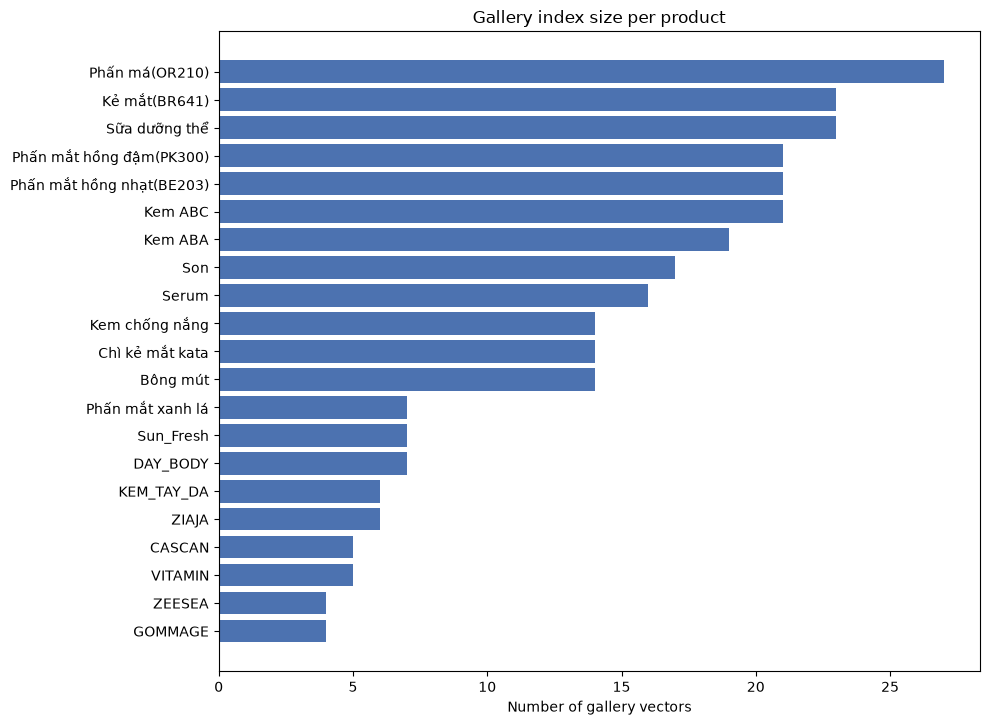

In [57]:
if not gallery_index_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(gallery_index_df))))
    label_col = "product_name" if "product_name" in gallery_index_df.columns else "product_id"
    clean_labels = gallery_index_df[label_col].apply(normalize_text)
    ax.barh(clean_labels, gallery_index_df["num_vectors"], color="#4C72B0")
    ax.set_xlabel("Number of gallery vectors")
    ax.set_title("Gallery index size per product")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 4. Retrieve Top-K for a real crop

Runs the mini upstream pipeline (Detector → Cropper) to produce a real `CropImage`, then calls `Retriever.retrieve()` on it — the exact input shape retrieval sees at runtime.

In [58]:
benchmark_images_dir = config.resolve_path(config.paths.benchmark_images_dir)
query_dir = config.resolve_path(config.paths.query_dir)
candidate_dir = benchmark_images_dir if benchmark_images_dir.exists() and any(
    benchmark_images_dir.iterdir()
) else query_dir

available_images = sorted([f for f in candidate_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS])
assert available_images, f"No images found in {candidate_dir}"

detector = Detector(config)
cropper = Cropper(config)
empty_refinement_template = lambda image_id: RefinementResult(image_id=image_id, triggered=False, backend="none")

sample_path = random.choice(available_images)
sample_image = load_image_data(sample_path)
sample_detections = detector.detect(sample_image)
sample_crops = cropper.crop(sample_image, sample_detections, empty_refinement_template(sample_image.image_id))

print(f"Sample image: {sample_path.name}")
print(f"Detections -> crops: {len(sample_crops)}")
assert sample_crops, "No crops produced for the sample image — pick a different one."

2026-09-03 19:25:52 | INFO     | src.detection.backends.rf_detr | Loading RF-DETR model class='RFDETRBase' kwargs={'pretrain_weights': 'weights/detector/checkpoint_best_ema.pth'}


[2026-09-03 19:25:53] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-09-03 19:25:53] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


2026-09-03 19:25:53 | INFO     | src.detection.backends.rf_detr | Optimizing RF-DETR for inference (dtype=float32 compile=False batch_size=1)
2026-09-03 19:25:53 | INFO     | src.detection.backends.rf_detr | RfDetrBackend initialized (variant='base' weights_path='weights/detector/checkpoint_best_ema.pth')
2026-09-03 19:25:53 | INFO     | src.detection.detector | Detector initialized with backend='rf_detr'
2026-09-03 19:25:53 | INFO     | src.detection.cropper | Cropper initialized with padding=4px target_size=(1024, 1024) use_refined_bbox=True
2026-09-03 19:25:53 | INFO     | src.detection.detector | Detector found 9 region(s) in image_id='7_jpg.rf.oQ4WxRz7iWKzjAEX7gd9' (651.25 ms)
2026-09-03 19:25:54 | INFO     | src.detection.cropper | Cropper produced 9 crop(s) for image_id='7_jpg.rf.oQ4WxRz7iWKzjAEX7gd9' (13.48 ms)
Sample image: 7_jpg.rf.oQ4WxRz7iWKzjAEX7gd9.jpg
Detections -> crops: 9


In [59]:
query_crop = sample_crops[0]

if retriever is not None:
    retrieval_result = retriever.retrieve(query_crop)

    retrieval_df = pd.DataFrame([
        {"rank": c.rank, "product_id": c.product_id, "product_name": c.product_name,
         "similarity_score": round(c.similarity_score, 4)}
        for c in retrieval_result.candidates
    ])
    print(f"Retrieval latency: {retrieval_result.processing_time_ms:.2f} ms")
    display(retrieval_df)
else:
    retrieval_result = None
    print("Retriever not available — skip.")

2026-09-03 19:25:54 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_e20468a6178e' (118.96 ms)
Retrieval latency: 118.96 ms


,rank,product_id,product_name,similarity_score
0,1,4,Bông mút,0.9391
1,2,4,Bông mút,0.9303
2,3,4,Bông mút,0.9219
3,4,4,Bông mút,0.9203
4,5,4,Bông mút,0.9131


## 5. Visualize the query crop next to its Top-K gallery matches

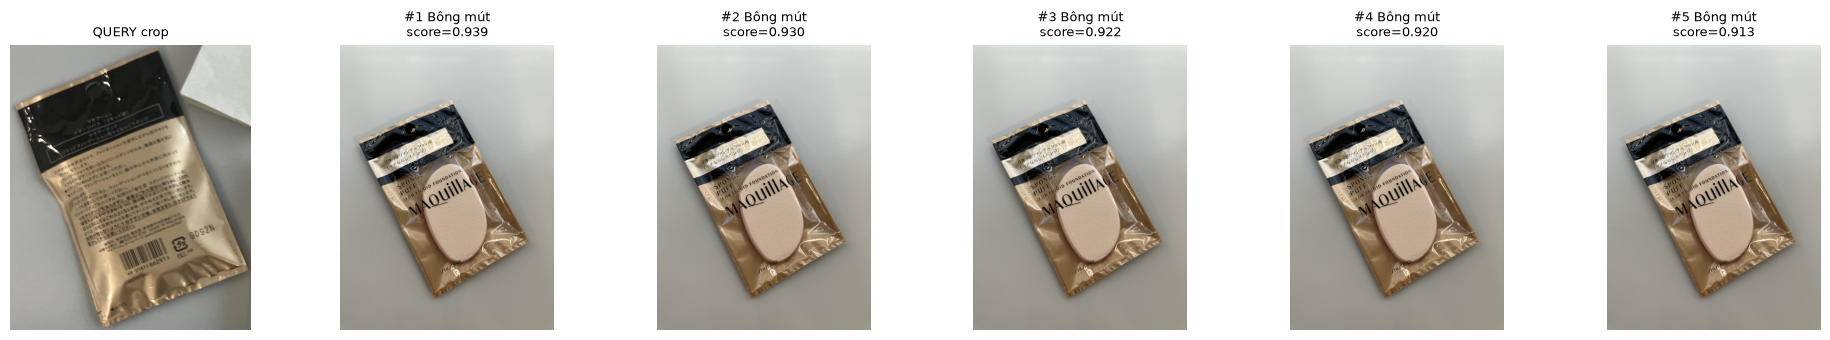

In [60]:
def load_representative_gallery_image(product_id: str):
    """Loads one representative image for a product using its catalog `folder` field."""
    if retriever is None:
        return None
    product = retriever.get_product(str(product_id))
    if product is None:
        return None
    folder_name = product.get("folder") or str(product_id)
    gallery_base = config.resolve_path(config.paths.gallery_dir)
    folder = gallery_base / folder_name
    if not folder.is_dir():
        folder = gallery_base / str(product_id)
        if not folder.is_dir():
            return None

    images = sorted([f for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTS])
    if not images:
        return None
    try:
        img_array = np.fromfile(str(images[0]), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        return img
    except Exception:
        return None


if retrieval_result is not None and retrieval_result.candidates:
    n_candidates = len(retrieval_result.candidates)
    fig, axes = plt.subplots(1, n_candidates + 1, figsize=(3.2 * (n_candidates + 1), 3.5))

    show_image_bgr(axes[0], query_crop.raw_image_array, title="QUERY crop")

    for i, candidate in enumerate(retrieval_result.candidates, start=1):
        gallery_image = load_representative_gallery_image(candidate.product_id)
        title = f"#{candidate.rank} {candidate.product_name}\nscore={candidate.similarity_score:.3f}"
        if gallery_image is not None:
            show_image_bgr(axes[i], gallery_image, title=title)
        else:
            axes[i].text(0.5, 0.5, "image not found", ha="center", va="center")
            axes[i].set_title(title, fontsize=9)
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No retrieval result to visualize.")

## 6. Self-retrieval sanity check

Feeds an actual gallery image straight back into `Retriever.retrieve()` (bypassing Detector/Cropper). With a deterministic embedding backend, the image's own product should come back as the Top-1 match — a quick smoke test that the index, metadata, and backend are all consistent with each other.

In [61]:
# Helper: Safe image reader for Windows/Unicode paths
def read_image_cv2_safe(image_path: Path):
    """Đọc ảnh an toàn trên Windows, hỗ trợ đường dẫn Unicode/ký tự đặc biệt."""
    image_path = Path(image_path)

    if not image_path.is_file():
        print(f"[WARN] Image file does not exist: {image_path}")
        return None

    try:
        data = np.fromfile(str(image_path), dtype=np.uint8)
        if data.size == 0:
            print(f"[WARN] Image file is empty: {image_path}")
            return None

        image = cv2.imdecode(data, cv2.IMREAD_COLOR)
        if image is None:
            print(f"[WARN] OpenCV could not decode image: {image_path}")
            return None

        return image
    except Exception as exc:
        print(f"[WARN] Failed to read image '{image_path}': {exc}")
        return None

In [64]:
# ============================================================
# 6. Self-retrieval sanity check
# ============================================================

if retriever is not None and not gallery_index_df.empty:

    sample_product_id = str(gallery_index_df.iloc[0]["product_id"])
    sample_product = retriever.get_product(sample_product_id)

    if sample_product is None:
        print(f"[WARN] Product not found: {sample_product_id}")
    else:
        # Resolve gallery folder path
        folder_name = sample_product.get("folder") or sample_product_id
        gallery_base = config.resolve_path(config.paths.gallery_dir)
        folder = gallery_base / folder_name

        # Fallback path by product_id
        if not folder.is_dir():
            folder = gallery_base / sample_product_id

        if not folder.is_dir():
            print(f"[WARN] Gallery folder not found: {folder}")
        else:
            gallery_images = sorted(
                f for f in folder.iterdir()
                if f.is_file() and f.suffix.lower() in IMAGE_EXTS
            )

            if not gallery_images:
                print(f"[WARN] No gallery images found in: {folder}")
            else:
                sample_image_path = gallery_images[0]
                product_name = sample_product.get("name", sample_product.get("product_name", ""))

                print(f"Product ID : {sample_product_id}")
                print(f"Product    : {product_name}")
                print(f"Image      : {sample_image_path}")

                # Read image safely
                raw = read_image_cv2_safe(sample_image_path)

                if raw is None:
                    print("[ERROR] Cannot read gallery image. Self-retrieval sanity check skipped.")
                else:
                    print(f"Original image shape: {raw.shape}")

                    # Resize to CropImage target size
                    target_size = tuple(config.cropping.target_size)
                    if len(target_size) != 2:
                        raise ValueError(
                            f"config.cropping.target_size must contain (width, height), got: {target_size}"
                        )

                    resized = cv2.resize(raw, target_size, interpolation=cv2.INTER_AREA)

                    # ------------------------------------------------
                    # Build CropImage query object
                    # ------------------------------------------------
                    height, width = resized.shape[:2]

                    self_query_crop = CropImage(
                        crop_id=generate_id(prefix="crop_"),
                        image_id=f"self_retrieval_{sample_image_path.stem}",
                        image_array=resized,
                        raw_image_array=resized.copy(),
                        source_bbox=BoundingBox(
                            x1=0,
                            y1=0,
                            x2=width,
                            y2=height,
                        ),
                        detection_confidence=1.0,
                        detection_index=0,
                        used_refined_bbox=False,
                    )

                    # ------------------------------------------------
                    # Retrieve
                    # ------------------------------------------------
                    result = retriever.retrieve(self_query_crop)

                    print("\nSelf-retrieval results:")

                    if result.candidates:
                        for candidate in result.candidates:
                            print(
                                f"  #{candidate.rank}: "
                                f"product_id={candidate.product_id}, "
                                f"name={candidate.product_name}, "
                                f"score={candidate.similarity_score:.4f}"
                            )

                    if result.top_candidate is None:
                        print("\n[WARN] No Top-1 candidate returned.")

                    else:
                        top1 = result.top_candidate

                        print("\nTop-1:")
                        print(f"  product_id  : {top1.product_id}")
                        print(f"  product_name: {top1.product_name}")
                        print(f"  score       : {top1.similarity_score:.4f}")

                        if str(top1.product_id) == sample_product_id:
                            print("\n[PASS] Self-retrieval returned the correct product as Top-1.")
                        else:
                            print("\n[FAIL] Self-retrieval did NOT return the same product as Top-1.")
                            print(f"       Expected: {sample_product_id}")
                            print(f"       Got     : {top1.product_id}")



Product ID : 3
Product    : Phấn má（OR210）
Image      : G:\VsCode\Python\DACN\stocktaking_ai_mini\data\gallery\インテグレート　フォルミングチークス（OR210）\IMG_0517.jpg
Original image shape: (4032, 3024, 3)
2026-09-03 19:28:53 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_c13938ed8897' (57.21 ms)

Self-retrieval results:
  #1: product_id=3, name=Phấn má（OR210）, score=0.9998
  #2: product_id=3, name=Phấn má（OR210）, score=0.8999
  #3: product_id=3, name=Phấn má（OR210）, score=0.8904
  #4: product_id=3, name=Phấn má（OR210）, score=0.8870
  #5: product_id=3, name=Phấn má（OR210）, score=0.8803

Top-1:
  product_id  : 3
  product_name: Phấn má（OR210）
  score       : 0.9998

[PASS] Self-retrieval returned the correct product as Top-1.


## 7. Top-1 similarity-score distribution across a batch

In [65]:
if retriever is not None:
    BATCH_SIZE = min(8, len(available_images))
    batch_paths = random.sample(available_images, k=BATCH_SIZE)

    top1_scores = []
    for path in batch_paths:
        img = load_image_data(path)
        det_result = detector.detect(img)
        crops = cropper.crop(img, det_result, empty_refinement_template(img.image_id))
        for crop in crops:
            result = retriever.retrieve(crop)
            if result.top_candidate is not None:
                top1_scores.append(result.top_candidate.similarity_score)

    print(f"Crops retrieved: {len(top1_scores)} (from {BATCH_SIZE} images)")
    if top1_scores:
        print(pd.Series(top1_scores, name="top1_similarity").describe())
else:
    top1_scores = []
    print("Retriever not available — skip.")

2026-09-03 19:29:07 | INFO     | src.detection.detector | Detector found 7 region(s) in image_id='IMG_0580_jpg.rf.kGqGE7TQtCKKOLykAyLN' (364.36 ms)
2026-09-03 19:29:07 | INFO     | src.detection.cropper | Cropper produced 7 crop(s) for image_id='IMG_0580_jpg.rf.kGqGE7TQtCKKOLykAyLN' (8.71 ms)
2026-09-03 19:29:07 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_62d0aaf8797a' (49.22 ms)
2026-09-03 19:29:07 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_a126e3c3368b' (47.16 ms)
2026-09-03 19:29:07 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_caac144d1767' (46.51 ms)
2026-09-03 19:29:07 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_7fbfd16eed33' (45.81 ms)
2026-09-03 19:29:07 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_9d78b332eab6' (44.93 ms)
2026-09-03 19:29:07 | INFO

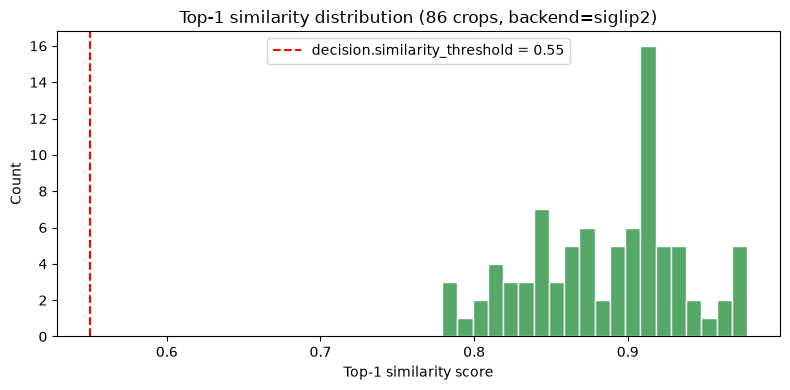

In [66]:
if top1_scores:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(top1_scores, bins=20, color="#55A868", edgecolor="white")
    ax.axvline(config.decision.similarity_threshold, color="red", linestyle="--",
               label=f"decision.similarity_threshold = {config.decision.similarity_threshold}")
    ax.set_xlabel("Top-1 similarity score")
    ax.set_ylabel("Count")
    ax.set_title(f"Top-1 similarity distribution ({len(top1_scores)} crops, backend={config.retrieval.backend})")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 8. Retrieval accuracy against benchmark ground truth

Only meaningful for images with COCO annotations (`data/benchmark/`). Per the README, `category_id` maps directly to the internal `product_id`. Each predicted crop is matched to its closest ground-truth box by IoU, then we check whether `Retriever`'s Top-1 product agrees with that ground-truth `category_id`.

This mirrors what VAL's Retrieval-stage evaluator measures (`top1_accuracy`), but on a small ad-hoc sample here — see `08_validation_benchmark.ipynb` for the full run.

In [67]:
benchmark_labels_path = config.resolve_path(config.paths.benchmark_labels_dir)
coco = None
if benchmark_labels_path.is_file():
    with open(benchmark_labels_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

if retriever is not None and coco is not None:
    IOU_MATCH_THRESHOLD = config.validation.iou_match_threshold
    image_lookup = {im["file_name"]: im for im in coco["images"]}
    anns_by_image_id = {}
    for ann in coco["annotations"]:
        anns_by_image_id.setdefault(ann["image_id"], []).append(ann)

    EVAL_SAMPLE_SIZE = min(8, len(available_images))
    eval_paths = [p for p in random.sample(available_images, k=min(20, len(available_images)))
                  if p.name in image_lookup][:EVAL_SAMPLE_SIZE]

    eval_rows = []
    for path in eval_paths:
        image_meta = image_lookup[path.name]
        gt_anns = anns_by_image_id.get(image_meta["id"], [])
        if not gt_anns:
            continue

        img = load_image_data(path)
        det_result = detector.detect(img)
        crops = cropper.crop(img, det_result, empty_refinement_template(img.image_id))

        for crop in crops:
            best_iou, best_gt = 0.0, None
            for ann in gt_anns:
                x, y, w, h = ann["bbox"]
                gt_box = BoundingBox(x1=x, y1=y, x2=x + w, y2=y + h)
                iou = crop.source_bbox.iou(gt_box)
                if iou > best_iou:
                    best_iou, best_gt = iou, ann

            if best_gt is None or best_iou < IOU_MATCH_THRESHOLD:
                continue  # crop does not correspond to any ground-truth instance

            result = retriever.retrieve(crop)
            if result.top_candidate is None:
                continue

            eval_rows.append({
                "image": path.name,
                "gt_category_id": str(best_gt["category_id"]),
                "predicted_top1_id": result.top_candidate.product_id,
                "top1_score": round(result.top_candidate.similarity_score, 4),
                "correct": str(best_gt["category_id"]) == result.top_candidate.product_id,
                "match_iou": round(best_iou, 3),
            })

    eval_df = pd.DataFrame(eval_rows)
    if not eval_df.empty:
        display(eval_df)
        accuracy = eval_df["correct"].mean()
        print(f"Ad-hoc Top-1 accuracy over {len(eval_df)} matched crop(s): {accuracy:.3f}")
    else:
        print("No matched crops found in this sample — try re-running or increasing the sample size.")
else:
    eval_df = pd.DataFrame()
    print("Retriever or benchmark annotations unavailable — skip.")

2026-09-03 19:29:22 | INFO     | src.detection.detector | Detector found 6 region(s) in image_id='IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR' (357.38 ms)
2026-09-03 19:29:22 | INFO     | src.detection.cropper | Cropper produced 6 crop(s) for image_id='IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR' (11.89 ms)
2026-09-03 19:29:22 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_c6b1ecc03fe3' (20.26 ms)
2026-09-03 19:29:22 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_2ae2599764fa' (22.55 ms)
2026-09-03 19:29:22 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_55816daf2ee5' (20.29 ms)
2026-09-03 19:29:22 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_ef216cd026b6' (23.65 ms)
2026-09-03 19:29:22 | INFO     | src.retrieval.retriever | Retriever returned 5 candidate(s) for crop_id='crop_644b49f4ba75' (20.56 ms)
2026-09-03 19:29:22 | INF

,image,gt_category_id,predicted_top1_id,top1_score,correct,match_iou
0,IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR.jpg,8,8,0.8686,True,0.981
1,IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR.jpg,7,8,0.8853,False,0.957
2,IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR.jpg,7,7,0.8919,True,0.953
3,IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR.jpg,8,7,0.8562,False,0.923
4,IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR.jpg,8,7,0.9141,False,0.969
...,...,...,...,...,...,...
82,IMG_0574_jpg.rf.R2bKfd2LrDlvBTTeW2CC.jpg,7,2,0.8169,False,0.963
83,IMG_0574_jpg.rf.R2bKfd2LrDlvBTTeW2CC.jpg,5,5,0.9110,True,0.945
84,IMG_0574_jpg.rf.R2bKfd2LrDlvBTTeW2CC.jpg,7,2,0.8673,False,0.942
85,IMG_0574_jpg.rf.R2bKfd2LrDlvBTTeW2CC.jpg,8,8,0.7853,True,0.935


Ad-hoc Top-1 accuracy over 87 matched crop(s): 0.747


## 9. Summary

In [68]:
summary = {
    "Gallery vectors": len(gallery_metadata) if "gallery_metadata" in dir() and gallery_metadata_path.is_file() else 0,
    "Distinct products in index": len(product_id_counts) if "product_id_counts" in dir() else 0,
    "Crops retrieved (batch, §7)": len(top1_scores),
    "Ad-hoc Top-1 accuracy (§8)": f"{eval_df['correct'].mean():.3f}" if not eval_df.empty else "n/a",
}
pd.DataFrame([summary]).T.rename(columns={0: "Value"})

,Value
Gallery vectors,281
Distinct products in index,21
"Crops retrieved (batch, §7)",86
Ad-hoc Top-1 accuracy (§8),0.747


---
**Quick observations (fill in after running on real data):**

- Are any products under-represented in the gallery index (§3)? Those are the ones most likely to have poor retrieval accuracy.
- Did the self-retrieval sanity check (§6) return the queried image's own product as Top-1? If not, something is inconsistent between the FAISS index, `gallery_metadata.json`, and the embedding backend.
- Where does the Top-1 similarity distribution (§7) sit relative to `decision.similarity_threshold` (0.55)? A lot of mass just below the threshold suggests many crops will route to `uncertain`/plugin fusion rather than being accepted outright.
- How does the ad-hoc Top-1 accuracy (§8) compare to the README's reported 0.735 on the full 287-crop benchmark? A small sample here can look very different — check `08_validation_benchmark.ipynb` for the full picture.

**Next notebook:** `05_decision_reranking.ipynb` — how `DecisionEngine` turns these Top-K candidates into accept/uncertain/reject decisions, and how `Reranker` fuses OCR/Color/Barcode evidence back in.
